# Prompt Optimization



Similar to ML, prompt optimization is a data-driven process.

With prompt programming, we seek to find the prompt that maximizes the specified **metric function** for our validation data set. As with ML, this is an automated and a data-driven approach, where DSPy generates many candidate prompts and methodically tests them with the validation set against the LM.

Of course when we try to solve a problem with an LM, we can can use stronger (and more expensive) model, fine-tune the model, or improve the prompt. All of these are valid methods, but the cost of improving the prompt is the lowest. We should always consider prompt optimization first.

What tools are available to us for prompt improvement?

- **Use clearer labels**. Class names are important because an LM will rely on their semantic meaning. That is why we often re-label, rename the labels.
- **Provide demonstrations in the prompt**. With enough demonstration, an LM can pick the pattern.
- **Extend or improve instructions**. We can keep writing instructions what role an LM is playing and how it should behave.

All three approaches are worth pursuing. But the objective of this notebook is to demonstrate how we can improve (a) **demonstrations included into a prompt** and (b) **the instructions**.

> "demonstrations" - input and output included in a prompt

Research from the DSPy team has shown that optimizing the demos can be considerably more effective than optimizing the instructions! Optimizing the demonstrations can be a good place to start and often is enough to create a strong prompt. _This is interesting, as
prompt engineering tends to focus primarily on the instructions_.

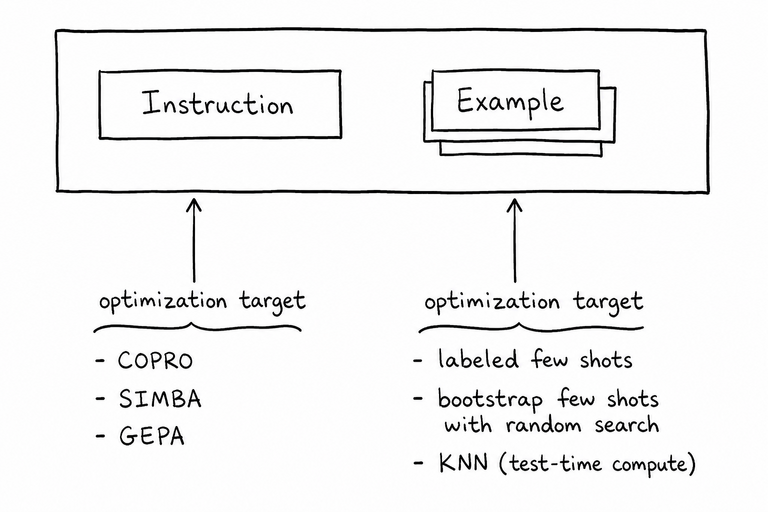

# Optimization Problem Statement 

In [1]:
import os
import pandas as pd
import numpy as np
import dspy
from dotenv import load_dotenv
from datasets import load_dataset
from typing import List, Literal

In [41]:
lm = dspy.LM(
    model="openrouter/google/gemma-4-26b-a4b-it",
    api_base="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)
dspy.configure(lm=lm)

In [27]:
print(lm("Say 'Hi!' back to me!"))

['Hi!']


In [28]:
def validate_answer(example: dspy.Example, prediction: dspy.Prediction, trace=None):
    return example.intent_label == prediction.intent_label

In [29]:
# class IntentSignature(dspy.Signature):
#    """
#    Classify the message into one of the possible labels.
#    """
#    message: str      = dspy.InputField() 
#    labels: List[str] = dspy.InputField()
#    intent_label: str = dspy.OutputField() 
 
class ClosedIntentSignature(dspy.Signature):
    """
    Classify the message into one of the possible labels.
    """
    message: str = dspy.InputField()
    intent_label: Literal[
        "Abbreviation and Fare Code Meaning Inquiry",
        "Aircraft Type Inquiry",  
        "Airfare and Fees Questions",  
        "Airline Information Request",  
        "Airport Information and Queries",
        "Aircraft Seating Capacity Inquiry",
        "Cheapest Fare Inquiry",
        "Airport Location Inquiry",
        "Airport Distance Inquiry",
        "Flight Booking Request",
        "Flight Number Inquiry",
        "Time Inquiry",
        "Ground Transportation Cost Inquiry",
        "Ground Transportation Inquiry",
        "Inquiry about In-flight Meals",
        "Flight Quantity Inquiry",
        "Flight Restriction Inquiry"
    ] = dspy.OutputField()
 
intent_classifier = dspy.Predict(ClosedIntentSignature)

In [30]:
prediction = intent_classifier(
     message="What meals are served on the 3pm flight to Madrid?")
print(prediction)

Prediction(
    intent_label='Inquiry about In-flight Meals'
)


We now have `intent_classifier` - an unoptimized DSPy program. This is the program we will try to optimize!

# The LabeledFewShot optimizer

In [31]:
import numpy
import dspy
from datasets import load_dataset

In [32]:
ATIS_INTENT_MAPPING = {
   'abbreviation':                "Abbreviation and Fare Code Meaning Inquiry",
   'aircraft':                    "Aircraft Type Inquiry",
  #'aircraft+flight+flight_no':   "",
   'airfare':                     "Airfare and Fees Questions",
  #'airfare+flight_time':         "",
   'airline':                     "Airline Information Request",
  #'airline+flight_no':           "",
   'airport':                     "Airport Information and Queries",
   'capacity':                    "Aircraft Seating Capacity Inquiry",
   'Cheapest':                    "Cheapest Fare Inquiry",
   'city':                        "Airport Location Inquiry",
   'distance':                    "Airport Distance Inquiry",
   'flight':                      "Flight Booking Request",
  #'flight+airfare':              "",
   'flight_no':                   "Flight Number Inquiry",
   'flight_time':                 "Time Inquiry",
   'ground_fare':                 "Ground Transportation Cost Inquiry",
   'ground_service':              "Ground Transportation Inquiry",
  #'ground_service+ground_fare':  "Airport Ground Transportation and Cost Query",
   'meal':                        "Inquiry about In-flight Meals",
   'quantity':                    "Flight Quantity Inquiry",
   'restriction':                 "Flight Restriction Inquiry"
}
 
def create_examples_from_set(set_name, n=-1):
   ds = load_dataset("tuetschek/atis")
   ds.set_format(type='pandas')
   df = ds[set_name][:] 
   df['intent'] = df['intent'].map(ATIS_INTENT_MAPPING)
   df = df.dropna(subset='intent')
   if n > 0:
      df = df.sample(n=n, random_state=42) 
 
   examples = []
   for index in df.index: 
       row = df.loc[index]
       examples.append(
           dspy.Example(message=row['text'],
               intent_label=row['intent']).with_inputs('message')
       )
   return examples

In [33]:
train_val_set = create_examples_from_set('test')
np.random.shuffle(train_val_set)
train_set = train_val_set[:100]
val_set = train_val_set[100:400]  
 
dev_test_set = create_examples_from_set('train')
np.random.shuffle(dev_test_set )
dev_set = dev_test_set [:1000]
test_set = dev_test_set[1000:2000]
 
print(len(train_set), len(val_set), len(dev_set), len(test_set))

100 300 1000 1000


In [34]:
train_set[:2]

[Example({'message': 'show me ground transportation in fort worth', 'intent_label': 'Ground Transportation Inquiry'}) (input_keys={'message'}),
 Example({'message': 'i want a flight from montreal to washington dc', 'intent_label': 'Flight Booking Request'}) (input_keys={'message'})]

We now have everything we need to start optimizing `intent_classifier` program.

In [35]:
from dspy.teleprompt import LabeledFewShot

We begin with creating an instance of a `LabeledFewShot` optimizer by specifying one parameter, `k`, which indicates how many demonstrations should be included in the prompt. The optimizer will select four random Examples from the training set

In [36]:
num_examples = 4
labeled_few_shot_optimizer = LabeledFewShot(k=num_examples)

We now call a `compile()` method, which compiles one DSPy program into an optimized DSPy program. Calling `compile()` also requires passing the training set: the pool of Examples from which it will select four.

In [37]:
prog_labeled_few_shot = labeled_few_shot_optimizer.compile(student=intent_classifier, 
                                                           trainset=train_set)

In [38]:
%%time
prediction = prog_labeled_few_shot(**dev_set[0].inputs())

CPU times: user 56.4 ms, sys: 7.18 ms, total: 63.5 ms
Wall time: 3.24 s


In [39]:
print(prediction)
print(prog_labeled_few_shot.demos)

print(lm.inspect_history(n=1))

Prediction(
    intent_label='Cheapest Fare Inquiry'
)
[Example({'message': 'list flights from pittsburgh to newark on monday morning', 'intent_label': 'Flight Booking Request'}) (input_keys={'message'}), Example({'message': 'please give me the flights from nashville to houston nonstop with dinner served', 'intent_label': 'Flight Booking Request'}) (input_keys={'message'}), Example({'message': 'show me flights from milwaukee to orlando one way', 'intent_label': 'Flight Booking Request'}) (input_keys={'message'}), Example({'message': 'get flights between st. petersburg and charlotte', 'intent_label': 'Flight Booking Request'}) (input_keys={'message'})]




[2026-08-07T07:48:34.521623]

System message:

Your input fields are:
1. `message` (str):
Your output fields are:
1. `intent_label` (Literal['Abbreviation and Fare Code Meaning Inquiry', 'Aircraft Type Inquiry', 'Airfare and Fees Questions', 'Airline Information Request', 'Airport Information and Queries', 'Aircraft Seating Capacity I

In [42]:
evaluator = dspy.Evaluate(devset=val_set[50:],
                        num_threads=2,
                        display_progress=True, 
                        display_table=True, 
                        provide_traceback=False,
                        max_errors=0)

result = evaluator(prog_labeled_few_shot, metric=validate_answer)

Average Metric: 216.00 / 250 (86.4%): 100%|█████████████████████████████████████████████████████████████████████████████████| 250/250 [03:27<00:00,  1.21it/s]

2026/08/07 07:55:50 INFO dspy.evaluate.evaluate: Average Metric: 216 / 250 (86.4%)


,message,example_intent_label,pred_intent_label,validate_answer
0,what does fare code qo mean,Abbreviation and Fare Code Meaning Inquiry,Abbreviation and Fare Code Meaning Inquiry,✔️ [True]
1,how much is coach flight from pittsburgh to atlanta,Airfare and Fees Questions,Airfare and Fees Questions,✔️ [True]
2,show me the delta flights which serve a snack to coach passengers,Flight Booking Request,Inquiry about In-flight Meals,✔️ [False]
3,i would like flights from salt lake city to cincinnati,Flight Booking Request,Flight Booking Request,✔️ [True]
4,at the charlotte airport how many different types of aircraft are ...,Aircraft Type Inquiry,Aircraft Type Inquiry,✔️ [True]
...,...,...,...,...
245,what is seating capacity on the aircraft 73s,Aircraft Seating Capacity Inquiry,Aircraft Seating Capacity Inquiry,✔️ [True]
246,how many passengers can an l1011 aircraft hold,Aircraft Seating Capacity Inquiry,Aircraft Seating Capacity Inquiry,✔️ [True]
247,i 'll need to rent a car in washington dc,Ground Transportation Inquiry,Ground Transportation Inquiry,✔️ [True]
248,which airlines fly between toronto and san diego,Airline Information Request,Airline Information Request,✔️ [True]


In [43]:
result

EvaluationResult(score=86.4, results=<list of 250 results>)

The process of labels selection is random. We can write a loop with various number of samples, but it is still a random search. In contrast to some other optimizers, `LabeledFewShot` does not learn from experience. Optimizers that do learn from experience tend to work better, but random searches are still used extensively.

## Zero-shot → ChainOfThought

Let's switch from `Predict` to `ChainOfThought`!

In [44]:
intent_classifier_cof = dspy.ChainOfThought(ClosedIntentSignature)

In [45]:
labeled_few_shot_optimizer = LabeledFewShot(k=10)
few_shot_model = labeled_few_shot_optimizer.compile(student=intent_classifier_cof, 
                                                    trainset=train_set)

In [48]:
evaluator = dspy.Evaluate(devset=val_set[50:],
                        num_threads=5,
                        display_progress=True, 
                        display_table=False, 
                        provide_traceback=False,
                        max_errors=0)
result = evaluator(few_shot_model, metric=validate_answer)

Average Metric: 222.00 / 250 (88.8%): 100%|█████████████████████████████████████████████████████████████████████████████████| 250/250 [04:02<00:00,  1.03it/s]

2026/08/07 08:04:49 INFO dspy.evaluate.evaluate: Average Metric: 222 / 250 (88.8%)


In [49]:
result

EvaluationResult(score=88.8, results=<list of 250 results>)

In [50]:
print(lm.inspect_history(n=1))





[2026-08-07T08:04:49.950454]

System message:

Your input fields are:
1. `message` (str):
Your output fields are:
1. `reasoning` (str): 
2. `intent_label` (Literal['Abbreviation and Fare Code Meaning Inquiry', 'Aircraft Type Inquiry', 'Airfare and Fees Questions', 'Airline Information Request', 'Airport Information and Queries', 'Aircraft Seating Capacity Inquiry', 'Cheapest Fare Inquiry', 'Airport Location Inquiry', 'Airport Distance Inquiry', 'Flight Booking Request', 'Flight Number Inquiry', 'Time Inquiry', 'Ground Transportation Cost Inquiry', 'Ground Transportation Inquiry', 'Inquiry about In-flight Meals', 'Flight Quantity Inquiry', 'Flight Restriction Inquiry']):
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## message ## ]]
{message}

[[ ## reasoning ## ]]
{reasoning}

[[ ## intent_label ## ]]
{intent_label}        # note: the value you produce must exactly match (no extra characters) one of: Abbreviation and Fare Code 

# BootstrapFewShot

See [BootstrapFewShot family](https://dspy.ai/diving-deeper/bootstrap-fewshot-family/) for details.

`BootstrapFewShot` intended for more complex, multi-step modules that make multiple LM calls. A multi-step module could be designed for to answer complex questions. It first makes an LM call to break the question into simpler problems, then makes a series of other LM calls for each of the sub-questions, and then makes a final call to combine the previous results into the overall answer. When there are multiple LM calls, multiple prompts must also be optimized.

Normally the Examples we provide the optimizer contain only the inputs to the module (the inputs for the module’s first LM call) and the expected final outputs (the outputs from the module’s last LM call). But the Examples don't usually include the inputs or outputs of the intermediate LM calls. This is important because we shouldn’t need to concern ourselves with how the module works internally when we’re creating the Examples. We also shouldn’t need to know if it makes one LM call or many. This is what allows us to easily switch between modules. Nevertheless, when optimizing a module, if optimizing includes setting the demonstrations, DSPy will attempt to automatically provide demos for all of these intermediate LM calls, which is called **bootstrapping**.

It is indeed too much for our classification problem. We only use it as an example here. 

In [51]:
from dspy import BootstrapFewShot

Metric function is useful not only for evaluation, but also for bootstrapping. When bootstrapping, DSPy expects `True`/`False` value, not a numberical one. Metric functions include a parameter called trace, which may be used to determine if the function is being called for evaluation or for bootstrapping. When called for evaluation, trace is set to None; when called for bootstrapping, it won't be set to None.

In [58]:
optimizer = BootstrapFewShot(
    metric=validate_answer,
    max_bootstrapped_demos=4,
    max_labeled_demos=6,
    max_rounds=10
)

Since the selection is no longer a random process, it will take some time to call `compile()`.

In [54]:
prog_bootrstrap_few_shot = optimizer.compile(student=intent_classifier, 
                                             trainset=train_set)

  4%|████▊                                                                                                                    | 4/100 [00:00<00:01, 92.38it/s]

Bootstrapped 4 full traces after 4 examples for up to 10 rounds, amounting to 4 attempts.


In [56]:
dev_set[0].inputs()

Example({'message': 'cheapest fare from memphis to seattle'}) (input_keys={'message'})

prediction = prog_bootrstrap_few_shot(**dev_set[0].inputs())
print(lm.inspect_history(n=1))

`ChainOfThought` module will give us more! If we set only `max_labeled_demos` (for COT module) to a value greater than zero, it will behave the same as with LabeledFewShot. But, if we set `max_bootstrapped_demos` greater than zero, we see something interesting. This will add demonstrations (`[[ ## reasoning ## ]]`) to the prompt. This has a reasoning field filled in, which is actually what the term bootstrapping refers to (in this sense "bootstrapping" means _creating something from nothing_, not classical "bootstrap sampling". 

```
User message:
 
[[ ## message ## ]]
is there a flight on delta airlines from boston to denver
 
 
Assistant message:
 
[[ ## reasoning ## ]]
The message is asking about the availability of a flight on Delta Airlines from Boston to Denver. This indicates a request for information related to flight options, which falls under the category of flight booking inquiries.
 
[[ ## intent_label ## ]]
Flight Booking Request
 
[[ ## completed ## ]]
```

## Specifying a teacher

For many of the DSPy optimizers, we can provide what’s called a teacher LM for the optimization process. 

In [59]:
kimi_k3 = dspy.LM(
    model="openrouter/moonshotai/kimi-k3",
    api_base="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)

Using a teacher when bootstrapping allows LM-generated content to be generated by a stronger LM.

In [60]:
optimizer = BootstrapFewShot(
    metric=validate_answer,
    max_bootstrapped_demos=7,
    max_labeled_demos=5,
    max_rounds=10,
    teacher_settings=dict(lm=kimi_k3)
)
 
intent_classifier_cof = dspy.ChainOfThought(ClosedIntentSignature)
bootrstrap_few_shot = optimizer.compile(student=intent_classifier_cof, trainset=train_set)

  8%|█████████▋                                                                                                               | 8/100 [00:54<10:29,  6.84s/it]

Bootstrapped 7 full traces after 8 examples for up to 10 rounds, amounting to 17 attempts.


prediction = bootrstrap_few_shot(**dev_set[0].inputs())
print(lm.inspect_history(n=1))

## BootstrapFewShotWithRandomSearch

`BootstrapFewShot` selects examples completely at random.` BootstrapFewShotWithRandomSearch` optimizer works similarly to the `BootstrapFewShot`, but examines multiple sets of Examples and selects the set that performs the best on a validation set. 

In [62]:
from dspy import BootstrapFewShotWithRandomSearch

In [63]:
optimizer = BootstrapFewShotWithRandomSearch(
    metric=validate_answer,
    max_bootstrapped_demos=10,
    max_labeled_demos=5,
    num_threads=10,
    num_candidate_programs=10
)
 
intent_classifier_bootstrap_few_shot_with_random_search = optimizer.compile(
    intent_classifier,
    trainset=train_set,
    valset=val_set
)

Going to sample between 1 and 10 traces per predictor.
Will attempt to bootstrap 10 candidate sets.
Average Metric: 186.00 / 300 (62.0%): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:55<00:00,  5.45it/s]

2026/08/07 09:23:41 INFO dspy.evaluate.evaluate: Average Metric: 186 / 300 (62.0%)



New best score: 62.0 for seed -3
Scores so far: [62.0]
Best score so far: 62.0
Average Metric: 255.00 / 300 (85.0%): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:59<00:00,  5.05it/s]

2026/08/07 09:24:40 INFO dspy.evaluate.evaluate: Average Metric: 255 / 300 (85.0%)



New best score: 85.0 for seed -2
Scores so far: [62.0, 85.0]
Best score so far: 85.0


...


Scores so far: [62.0, 85.0, 84.67, 85.67, 84.33, 85.33, 84.67, 81.0, 83.67, 85.67, 77.33, 76.0]
Best score so far: 85.67


  8%|█████████████▉                                                                                                                                                                | 8/100 [00:27<05:21,  3.49s/it]


Bootstrapped 8 full traces after 8 examples for up to 1 rounds, amounting to 8 attempts.
Average Metric: 254.00 / 300 (84.7%): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [01:19<00:00,  3.78it/s]

2026/08/07 09:38:12 INFO dspy.evaluate.evaluate: Average Metric: 254 / 300 (84.7%)



Scores so far: [62.0, 85.0, 84.67, 85.67, 84.33, 85.33, 84.67, 81.0, 83.67, 85.67, 77.33, 76.0, 84.67]
Best score so far: 85.67
13 candidate programs found.


In [64]:
pred = intent_classifier_bootstrap_few_shot_with_random_search(**dev_set[0].inputs())
print(lm.inspect_history(n=1))





[2026-08-07T09:38:14.855805]

System message:

Your input fields are:
1. `message` (str):
Your output fields are:
1. `intent_label` (Literal['Abbreviation and Fare Code Meaning Inquiry', 'Aircraft Type Inquiry', 'Airfare and Fees Questions', 'Airline Information Request', 'Airport Information and Queries', 'Aircraft Seating Capacity Inquiry', 'Cheapest Fare Inquiry', 'Airport Location Inquiry', 'Airport Distance Inquiry', 'Flight Booking Request', 'Flight Number Inquiry', 'Time Inquiry', 'Ground Transportation Cost Inquiry', 'Ground Transportation Inquiry', 'Inquiry about In-flight Meals', 'Flight Quantity Inquiry', 'Flight Restriction Inquiry']):
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## message ## ]]
{message}

[[ ## intent_label ## ]]
{intent_label}        # note: the value you produce must exactly match (no extra characters) one of: Abbreviation and Fare Code Meaning Inquiry; Aircraft Type Inquiry; Airfare and Fees Q